## Кредиты

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Загрузка датасета
df = pd.read_csv("cs-training.csv")
df.head()
df = df.drop(columns=[df.columns[0]])

print("Размер датасета:", df.shape)
print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nОбщая информация:")
print(df.info())

#Анализ пропусков
print("\nКоличество пропусков по столбцам:")
print(df.isna().sum())

#Удаление целевого столбца и выделение признаков
target_column = "SeriousDlqin2yrs"
X = df.drop(columns=[target_column])

print("Признаки для PCA:")
print(X.columns.tolist())

#Обработка пропусков с помощью SimpleImputer
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Пропуски после заполнения:")
print(X_imputed.isna().sum())



Размер датасета: (150000, 11)

Названия столбцов:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 

### Определение признаков вошедших в главные компоненты

In [3]:
pca_raw = PCA()
X_pca_raw = pca_raw.fit_transform(X_imputed)
explained_variance_raw = pd.DataFrame({
    "Главная компонента": [f"PC{i+1}" for i in range(len(pca_raw.explained_variance_ratio_))],
    "Доля объясненной дисперсии": pca_raw.explained_variance_ratio_,
    "Накопленная доля": np.cumsum(pca_raw.explained_variance_ratio_)
})

explained_variance_raw


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,9.752667e-01,0.975267
1,PC2,2.436543e-02,0.999632
2,PC3,3.660929e-04,0.999998
3,PC4,1.284426e-06,1.000000
4,PC5,3.035644e-07,1.000000
5,PC6,1.506009e-07,1.000000
6,PC7,7.072260e-09,1.000000
7,PC8,5.547810e-09,1.000000
8,PC9,1.767215e-09,1.000000
9,PC10,6.919898e-10,1.000000


### Матрица главных компонент

In [4]:
components_raw = pd.DataFrame(
    pca_raw.components_,
    columns=X_imputed.columns,
    index=[f"PC{i+1}" for i in range(len(X_imputed.columns))]
)
loadings_raw = components_raw.T
loadings_raw

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
RevolvingUtilizationOfUnsecuredLines,0.000126,0.000508,1.000000,0.000379,0.000026,0.000227,-0.000025,-0.000038,1.221295e-06,-1.419208e-06
age,0.000032,0.000179,-0.000367,0.997464,0.043560,-0.053351,0.016871,-0.005868,1.182760e-03,-7.308443e-04
NumberOfTime30-59DaysPastDueNotWorse,-0.000003,-0.000014,-0.000021,-0.023339,0.576175,0.059858,0.019121,0.000677,8.008663e-01,-1.488020e-01
DebtRatio,-0.002919,0.999996,-0.000508,-0.000188,0.000030,-0.000122,-0.000006,-0.000060,-5.579960e-07,9.332948e-08
MonthlyIncome,0.999996,0.002919,-0.000128,-0.000034,0.000007,-0.000034,-0.000008,-0.000004,2.149663e-07,-1.076779e-07
NumberOfOpenCreditLinesAndLoans,0.000035,0.000129,-0.000249,0.057179,-0.080348,0.989980,-0.067430,-0.074082,-1.321943e-02,-1.994213e-03
NumberOfTimes90DaysLate,-0.000003,-0.000017,-0.000016,-0.022763,0.574954,0.038718,-0.007580,-0.005212,-5.321712e-01,-6.197740e-01
NumberRealEstateLoansOrLines,0.000010,0.000068,0.000022,0.002742,-0.009363,0.096632,0.472933,0.875617,-1.327398e-02,-4.499567e-03
NumberOfTime60-89DaysPastDueNotWorse,-0.000003,-0.000016,-0.000016,-0.021582,0.573570,0.045590,-0.006642,0.004572,-2.733697e-01,7.705046e-01
NumberOfDependents,0.000006,-0.000024,0.000004,-0.016103,-0.005209,0.024377,0.878087,-0.477204,-1.798964e-02,6.002359e-03


### Состав главных компонент

In [5]:
for pc in components_raw.index:
    print(f"\n{pc}")
    print(components_raw.loc[pc].abs().sort_values(ascending=False).head(3))


PC1
MonthlyIncome                           0.999996
DebtRatio                               0.002919
RevolvingUtilizationOfUnsecuredLines    0.000126
Name: PC1, dtype: float64

PC2
DebtRatio                               0.999996
MonthlyIncome                           0.002919
RevolvingUtilizationOfUnsecuredLines    0.000508
Name: PC2, dtype: float64

PC3
RevolvingUtilizationOfUnsecuredLines    1.000000
DebtRatio                               0.000508
age                                     0.000367
Name: PC3, dtype: float64

PC4
age                                     0.997464
NumberOfOpenCreditLinesAndLoans         0.057179
NumberOfTime30-59DaysPastDueNotWorse    0.023339
Name: PC4, dtype: float64

PC5
NumberOfTime30-59DaysPastDueNotWorse    0.576175
NumberOfTimes90DaysLate                 0.574954
NumberOfTime60-89DaysPastDueNotWorse    0.573570
Name: PC5, dtype: float64

PC6
NumberOfOpenCreditLinesAndLoans         0.989980
NumberRealEstateLoansOrLines            0.096632
NumberO

### Определение признаков вошедших в главные компоненты при стандантизированных данных

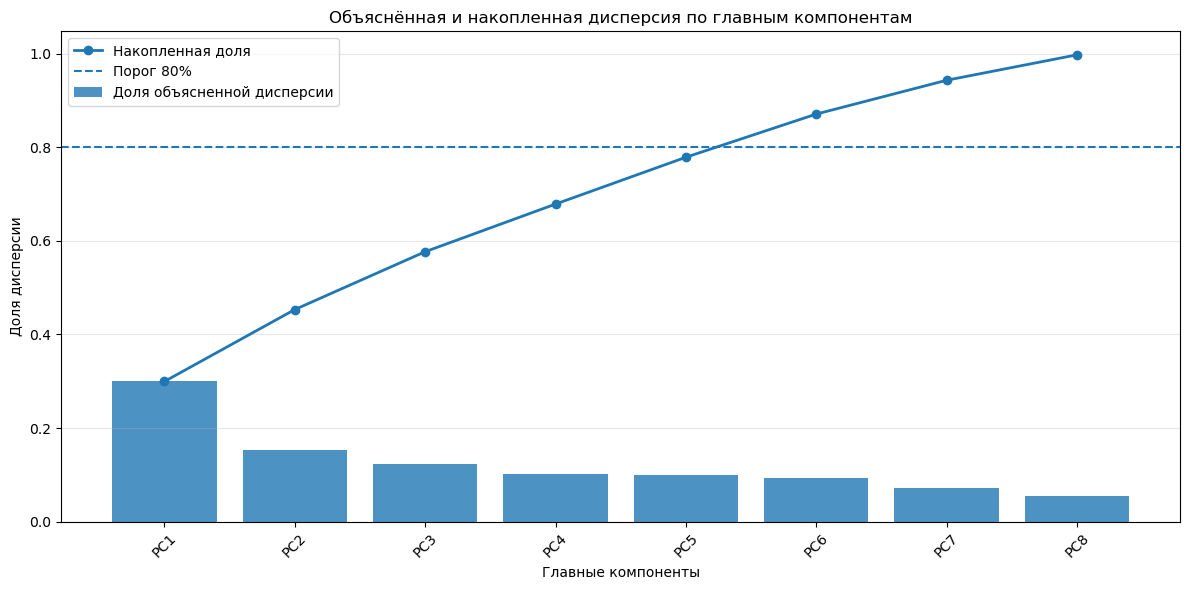

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled = pd.DataFrame(X_scaled, columns=X_imputed.columns)
X_scaled.head()

pca_scaled = PCA()
X_pca_scaled = pca_scaled.fit_transform(X_scaled)


explained_variance_scaled = pd.DataFrame({
    "Главная компонента": [f"PC{i+1}" for i in range(len(pca_scaled.explained_variance_ratio_))],
    "Доля объясненной дисперсии": pca_scaled.explained_variance_ratio_,
    "Накопленная доля": np.cumsum(pca_scaled.explained_variance_ratio_)
})

explained_variance_scaled

import matplotlib.pyplot as plt

n_scaled = (explained_variance_scaled["Накопленная доля"] < 0.95).sum() + 1
plot_data = explained_variance_scaled.iloc[:n_scaled]

plt.figure(figsize=(12, 6))
plt.bar(
    plot_data["Главная компонента"],
    plot_data["Доля объясненной дисперсии"],
    alpha=0.8,
    label="Доля объясненной дисперсии"
)
plt.plot(
    plot_data["Главная компонента"],
    plot_data["Накопленная доля"],
    marker="o",
    linewidth=2,
    label="Накопленная доля"
)
plt.axhline(y=0.80, linestyle="--", linewidth=1.5, label="Порог 80%")

plt.title("Объяснённая и накопленная дисперсия по главным компонентам")
plt.xlabel("Главные компоненты")
plt.ylabel("Доля дисперсии")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Матрица главных компонент при стандратизированных данных

In [ ]:
components_scaled = pd.DataFrame(
    pca_scaled.components_,
    columns=X_scaled.columns,
    index=[f"PC{i+1}" for i in range(len(X_scaled.columns))]
)
loadings_scaled = components_scaled.T
loadings_scaled



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
RevolvingUtilizationOfUnsecuredLines,-0.000625,-0.002477,0.026863,0.130984,0.982122,-0.130165,0.010567,0.022273,0.000063,-0.000087
age,-0.058059,0.133845,-0.678262,-0.277739,0.041809,-0.085783,0.632373,-0.180294,0.004566,-0.002646
NumberOfTime30-59DaysPastDueNotWorse,0.572311,0.066971,-0.019778,-0.006376,-0.000431,-0.014218,0.009808,0.013243,0.802875,-0.149871
DebtRatio,-0.011903,0.181918,-0.204639,0.764370,-0.029007,0.539911,0.185407,0.117920,-0.000320,0.000023
MonthlyIncome,-0.015496,0.266655,0.114463,-0.553028,0.170946,0.756385,-0.069827,0.059129,0.000532,-0.000337
NumberOfOpenCreditLinesAndLoans,-0.076481,0.631204,-0.108607,-0.048746,-0.042914,-0.298542,-0.119351,0.689967,-0.016899,-0.002520
NumberOfTimes90DaysLate,0.574323,0.049247,-0.023390,-0.007738,0.001158,-0.006513,0.013736,-0.001246,-0.530321,-0.621005
NumberRealEstateLoansOrLines,-0.053006,0.653612,0.044980,0.111513,-0.012541,-0.123993,-0.258119,-0.688011,-0.002643,-0.001067
NumberOfTime60-89DaysPastDueNotWorse,0.574567,0.055964,-0.026567,-0.008744,0.001098,-0.009014,0.013107,0.002283,-0.271706,0.769334
NumberOfDependents,-0.008661,0.205452,0.684688,0.024790,-0.040276,-0.085145,0.692398,0.000954,-0.003638,0.001424


In [ ]:
for pc in components_scaled.index:
    print(f"\n{pc}")
    print(components_scaled.loc[pc].abs().sort_values(ascending=False).head(3))


PC1
NumberOfTime60-89DaysPastDueNotWorse    0.574567
NumberOfTimes90DaysLate                 0.574323
NumberOfTime30-59DaysPastDueNotWorse    0.572311
Name: PC1, dtype: float64

PC2
NumberRealEstateLoansOrLines       0.653612
NumberOfOpenCreditLinesAndLoans    0.631204
MonthlyIncome                      0.266655
Name: PC2, dtype: float64

PC3
NumberOfDependents    0.684688
age                   0.678262
DebtRatio             0.204639
Name: PC3, dtype: float64

PC4
DebtRatio        0.764370
MonthlyIncome    0.553028
age              0.277739
Name: PC4, dtype: float64

PC5
RevolvingUtilizationOfUnsecuredLines    0.982122
MonthlyIncome                           0.170946
NumberOfOpenCreditLinesAndLoans         0.042914
Name: PC5, dtype: float64

PC6
MonthlyIncome                      0.756385
DebtRatio                          0.539911
NumberOfOpenCreditLinesAndLoans    0.298542
Name: PC6, dtype: float64

PC7
NumberOfDependents              0.692398
age                             0.63237

По этой таблице видно, что для стандартизированных данных главные компоненты уже формируются не отдельными признаками, а их сочетаниями. Первая компонента в основном связана с показателями **просрочек платежей**, вторая – с **кредитной нагрузкой и займами**, третья – с **возрастом и количеством иждивенцев**. Это говорит о том, что после стандартизации влияние масштаба признаков устранено, и метод главных компонент лучше отражает реальную структуру взаимосвязей между признаками.

In [ ]:
print("Нестандартизированные данные:")
display(explained_variance_raw.head())

print("Стандартизированные данные:")
display(explained_variance_scaled.head())

Нестандартизированные данные:


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,9.752667e-01,0.975267
1,PC2,2.436543e-02,0.999632
2,PC3,3.660929e-04,0.999998
3,PC4,1.284426e-06,1.000000
4,PC5,3.035644e-07,1.000000


Стандартизированные данные:


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,0.299500,0.299500
1,PC2,0.153743,0.453243
2,PC3,0.123589,0.576832
3,PC4,0.101805,0.678637
4,PC5,0.100113,0.778750


## Дома

In [ ]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("kc_house_data.csv")
df.head()

print("Размер датасета:", df.shape)
print("\nСтолбцы:")
print(df.columns.tolist())

print("\nПропуски:")
print(df.isna().sum())

df = df.drop(columns=["id", "date"])

#Выделение целевого
target = "price"

y = df[target]
X = df.drop(columns=[target])

print("Целевой признак:", target)
print("\nПризнаки для PCA:")
print(X.columns.tolist())






Размер датасета: (21613, 21)

Столбцы:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Пропуски:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64
Целевой признак: price

Признаки для PCA:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Нестандартизированные данны

,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,0.883718,0.883718
1,PC2,0.115355,0.999073
2,PC3,0.000684,0.999757
3,PC4,0.000113,0.999870
4,PC5,0.000068,0.999939


Стандартизированные данные:


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,0.290501,0.290501
1,PC2,0.122297,0.412798
2,PC3,0.102491,0.515290
3,PC4,0.075880,0.591169
4,PC5,0.066973,0.658143


Нестандартизированные данные:


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,0.883718,0.883718
1,PC2,0.115355,0.999073


Стандартизированные данные:


,Главная компонента,Доля объясненной дисперсии,Накопленная доля
0,PC1,0.290501,0.290501
1,PC2,0.122297,0.412798
2,PC3,0.102491,0.515290
3,PC4,0.075880,0.591169
4,PC5,0.066973,0.658143
5,PC6,0.055721,0.713864
6,PC7,0.048513,0.762377
7,PC8,0.046456,0.808833
8,PC9,0.036522,0.845354
9,PC10,0.033395,0.878749


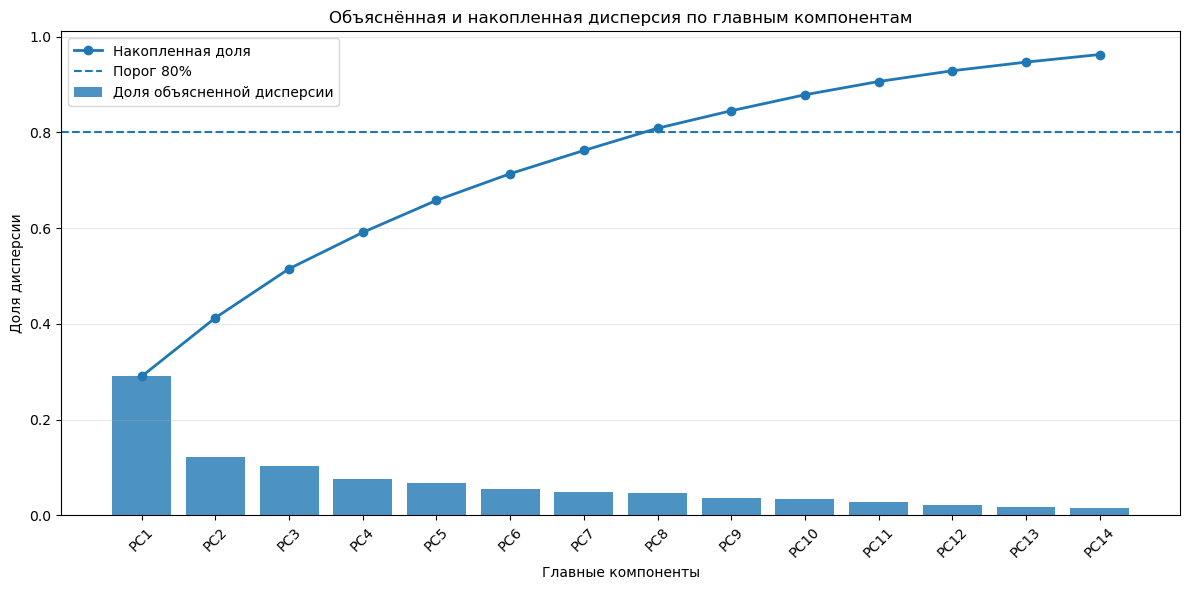

In [ ]:
# PCA для необработанных данных
pca_raw = PCA()
X_pca_raw = pca_raw.fit_transform(X_imputed)

#PCA для стандартизированных данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_scaled = PCA()
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

explained_variance_raw = pd.DataFrame({
    "Главная компонента": [f"PC{i+1}" for i in range(len(X_imputed.columns))],
    "Доля объясненной дисперсии": pca_raw.explained_variance_ratio_,
    "Накопленная доля": np.cumsum(pca_raw.explained_variance_ratio_)
})

explained_variance_scaled = pd.DataFrame({
    "Главная компонента": [f"PC{i+1}" for i in range(len(X_imputed.columns))],
    "Доля объясненной дисперсии": pca_scaled.explained_variance_ratio_,
    "Накопленная доля": np.cumsum(pca_scaled.explained_variance_ratio_)
})

# количество компонент до достижения 80% накопленной доли
n_raw = (explained_variance_raw["Накопленная доля"] < 0.95).sum() + 1
n_scaled = (explained_variance_scaled["Накопленная доля"] < 0.95).sum() + 1

print("Нестандартизированные данные:")
display(explained_variance_raw.iloc[:n_raw])

print("Стандартизированные данные:")
display(explained_variance_scaled.iloc[:n_scaled])

import matplotlib.pyplot as plt

plot_data = explained_variance_scaled.iloc[:n_scaled]

plt.figure(figsize=(12, 6))
plt.bar(
    plot_data["Главная компонента"],
    plot_data["Доля объясненной дисперсии"],
    alpha=0.8,
    label="Доля объясненной дисперсии"
)
plt.plot(
    plot_data["Главная компонента"],
    plot_data["Накопленная доля"],
    marker="o",
    linewidth=2,
    label="Накопленная доля"
)
plt.axhline(y=0.80, linestyle="--", linewidth=1.5, label="Порог 80%")

plt.title("Объяснённая и накопленная дисперсия по главным компонентам")
plt.xlabel("Главные компоненты")
plt.ylabel("Доля дисперсии")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Вычисление компонент

In [ ]:
components_raw_house = pd.DataFrame(
    pca_raw.components_,
    columns=X_imputed.columns,
    index=[f"PC{i+1}" for i in range(len(X_imputed.columns))]
)
components_scaled_house = pd.DataFrame(
    pca_scaled.components_,
    columns=X_imputed.columns,
    index=[f"PC{i+1}" for i in range(len(X_imputed.columns))]
)

In [ ]:
def get_top_features(components_df, top_n=3):
    rows = []

    for pc in components_df.index:
        sorted_features = components_df.loc[pc].abs().sort_values(ascending=False)
        top_features = sorted_features.head(top_n).index.tolist()
        top_values = components_df.loc[pc, top_features].tolist()

        row = {"Главная компонента": pc}
        for i in range(top_n):
            row[f"Признак_{i+1}"] = top_features[i]
            row[f"Коэффициент_{i+1}"] = top_values[i]
        rows.append(row)

    return pd.DataFrame(rows)

### Состав компонент для нестандартизированных

In [ ]:

for pc in components_raw_house.index:
    print(f"\n{pc}")
    print(components_raw_house.loc[pc].abs().sort_values(ascending=False).head(3))
    



PC1
sqft_lot       0.869621
sqft_lot15     0.493688
sqft_living    0.003672
Name: PC1, dtype: float64

PC2
sqft_lot15       0.869610
sqft_lot         0.493713
sqft_living15    0.003372
Name: PC2, dtype: float64

PC3
sqft_living      0.674480
sqft_above       0.585267
sqft_living15    0.440713
Name: PC3, dtype: float64

PC4
sqft_basement    0.805566
sqft_above       0.484997
sqft_living      0.320569
Name: PC4, dtype: float64

PC5
yr_renovated     0.748909
sqft_living15    0.592431
sqft_above       0.229219
Name: PC5, dtype: float64

PC6
sqft_living15    0.673989
yr_renovated     0.652799
sqft_living      0.275601
Name: PC6, dtype: float64

PC7
zipcode          0.986053
yr_built         0.164210
sqft_living15    0.019331
Name: PC7, dtype: float64

PC8
yr_built        0.986024
zipcode         0.164553
yr_renovated    0.015005
Name: PC8, dtype: float64

PC9
bedrooms    0.803079
view        0.441520
grade       0.387724
Name: PC9, dtype: float64

PC10
view        0.740198
bedrooms    0.53

### Состав компонент для стандартизированных

In [ ]:
for pc in components_scaled_house.index:
    print(f"\n{pc}")
    print(components_scaled_house.loc[pc].abs().sort_values(ascending=False).head(3))


PC1
sqft_living    0.394826
sqft_above     0.393106
grade          0.367615
Name: PC1, dtype: float64

PC2
sqft_basement    0.442190
long             0.375610
view             0.344723
Name: PC2, dtype: float64

PC3
sqft_lot15    0.553134
sqft_lot      0.547132
floors        0.336076
Name: PC3, dtype: float64

PC4
condition     0.386577
waterfront    0.355079
bedrooms      0.337384
Name: PC4, dtype: float64

PC5
waterfront    0.566547
lat           0.465858
view          0.396954
Name: PC5, dtype: float64

PC6
yr_renovated    0.887924
yr_built        0.189391
view            0.173138
Name: PC6, dtype: float64

PC7
lat          0.640744
long         0.368854
condition    0.272358
Name: PC7, dtype: float64

PC8
condition        0.642521
sqft_basement    0.450840
floors           0.340234
Name: PC8, dtype: float64

PC9
waterfront       0.539324
bedrooms         0.469022
sqft_living15    0.346807
Name: PC9, dtype: float64

PC10
bedrooms     0.451476
condition    0.398502
yr_built     0.34

Для стандартизированных данных первые пять главных компонент объясняют около 65.81% общей дисперсии, при этом наибольший вклад вносит первая компонента – 29.05%. Это означает, что после стандартизации информация распределена между компонентами более равномерно, и ни один отдельный признак не доминирует полностью.

По составу компонент видно, что:

- PC1 в основном связана с характеристиками размера и качества дома: sqft_living, sqft_above, grade;
- PC2 отражает признаки цокольной площади и расположения: sqft_basement, long, view;
- PC3 характеризует размер участка: sqft_lot15, sqft_lot, floors;
- PC4 связана с состоянием и особенностями объекта: condition, waterfront, bedrooms;
- PC5 в большей степени отражает местоположение и видовые характеристики: waterfront, lat, view.

Таким образом, для стандартизированных данных главные компоненты отражают не отдельные признаки, а смысловые группы характеристик недвижимости